In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [24]:
df = pd.read_csv("../data/group_A.csv", sep=';', decimal=',')

In [25]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
df['x'] = df['Position (m)'].apply(lambda x: format(float(x), '.20f'))

In [29]:
print(f"Min temp: {df['Temperature 1 (°C)'].min()}\nMax temp: {df['Temperature 2 (°C)'].max()}")

Min temp: 10.56
Max temp: 67.47


In [30]:
df

,Position (m),Absolute Pressure 2 (Pa),Temperature 1 (°C),Temperature 2 (°C),Volume (cm³)
0,0.000000e+00,87723.03,10.56,67.47,0.000000e+00
1,0.000000e+00,87725.91,NaN,NaN,0.000000e+00
2,0.000000e+00,87727.76,NaN,NaN,0.000000e+00
3,0.000000e+00,87729.60,NaN,NaN,0.000000e+00
4,0.000000e+00,87731.45,NaN,NaN,0.000000e+00
...,...,...,...,...,...
4836,1.680600e-16,87536.11,NaN,NaN,-6.880000e-13
4837,1.680600e-16,87535.30,NaN,NaN,-6.880000e-13
4838,1.680600e-16,87534.96,NaN,NaN,-6.880000e-13
4839,1.680600e-16,87534.84,NaN,NaN,-6.880000e-13


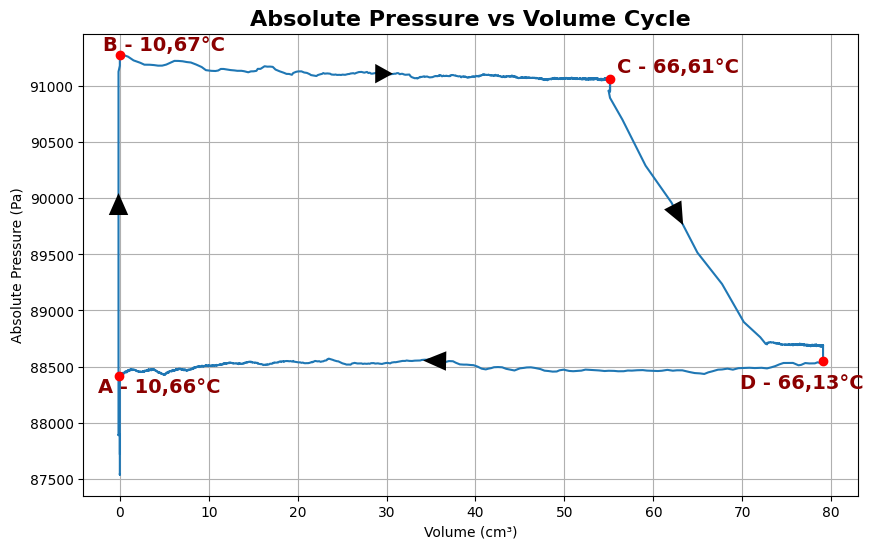

In [86]:
idx_a = 2036
idx_b = 2075
idx_c = 2920 
idx_d = 3858


points = {
    'A - 10,66°C': (df.iloc[idx_a]['Volume (cm³)'], df.iloc[idx_a]['Absolute Pressure 2 (Pa)']),
    'B - 10,67°C': (df.iloc[idx_b]['Volume (cm³)'], df.iloc[idx_b]['Absolute Pressure 2 (Pa)']),
    'C - 66,61°C': (df.iloc[idx_c]['Volume (cm³)'], df.iloc[idx_c]['Absolute Pressure 2 (Pa)']),
    'D - 66,13°C': (df.iloc[idx_d]['Volume (cm³)'], df.iloc[idx_d]['Absolute Pressure 2 (Pa)'])
}

# To use these in calculations later:
Va, Pa = points['A - 10,66°C']
Vb, Pb = points['B - 10,67°C']
Vc, Pc = points['C - 66,61°C']
Vd, Pd = points['D - 66,13°C']

plt.figure(figsize=(10,6))
plt.plot(df['Volume (cm³)'], df['Absolute Pressure 2 (Pa)'])

# 2. Plot and Label the Points
offsets = {
    'A - 10,66°C': (-15, -12),  # Shift A left and down
    'B - 10,67°C': (-12, 3),   # Shift B left and up
    'C - 66,61°C': (5, 5),    # Shift C right and up
    'D - 66,13°C': (-60, -20)    # Shift D right and down
}

for label, (v, p) in points.items():
    plt.scatter(v, p, color='red', zorder=5)
    
    # Use xytext to nudge the label away from the point
    plt.annotate(f'{label}', 
                 xy=(v, p), 
                 xytext=offsets[label], 
                 textcoords='offset points',
                 fontsize=14, 
                 fontweight='bold', 
                 color='darkred',
                 # Optional: add an arrow pointing from text to the dot
                 # arrowprops=dict(arrowstyle='->', color='black', lw=0.5) 
                )

# 3. Add Directional Arrows
# We add arrows at the midpoints of the transitions
# A -> B arrow
idx_ab_mid = 2053
idx_bc_mid = 2167
idx_cd_mid = 3225
idx_da_mid = 3946

plt.annotate('', 
             # End point (tip of the triangle)
             xy=(df.iloc[idx_ab_mid + 3]['Volume (cm³)'], 
                 df.iloc[idx_ab_mid + 3]['Absolute Pressure 2 (Pa)']),
             # Start point
             xytext=(df.iloc[idx_ab_mid]['Volume (cm³)'], 
                     df.iloc[idx_ab_mid]['Absolute Pressure 2 (Pa)']),
             arrowprops=dict(
                 arrowstyle="wedge,tail_width=0.7", # 'wedge' creates the solid triangle head
                 color='black', 
                 patchA=None, 
                 patchB=None, 
                 mutation_scale=20, # Increase this to make the arrow wider/bigger
                 lw=0               # Set line width to 0 to remove any 'tail' line
             ))

plt.annotate('', 
             # End point (tip of the triangle)
             xy=(df.iloc[idx_bc_mid + 15]['Volume (cm³)'], 
                 df.iloc[idx_bc_mid + 15]['Absolute Pressure 2 (Pa)']),
             # Start point
             xytext=(df.iloc[idx_bc_mid]['Volume (cm³)'], 
                     df.iloc[idx_bc_mid]['Absolute Pressure 2 (Pa)']),
             arrowprops=dict(
                 arrowstyle="wedge,tail_width=0.7", # 'wedge' creates the solid triangle head
                 color='black', 
                 patchA=None, 
                 patchB=None, 
                 mutation_scale=20, # Increase this to make the arrow wider/bigger
                 lw=0               # Set line width to 0 to remove any 'tail' line
             ))

plt.annotate('', 
             # End point (tip of the triangle)
             xy=((df.iloc[idx_cd_mid + 1]['Volume (cm³)']+df.iloc[idx_cd_mid]['Volume (cm³)'])/2, 
                 (df.iloc[idx_cd_mid + 1]['Absolute Pressure 2 (Pa)']+df.iloc[idx_cd_mid]['Absolute Pressure 2 (Pa)'])/2),
             # Start point
             xytext=(df.iloc[idx_cd_mid]['Volume (cm³)'], 
                     df.iloc[idx_cd_mid]['Absolute Pressure 2 (Pa)']),
             arrowprops=dict(
                 arrowstyle="wedge,tail_width=0.7", # 'wedge' creates the solid triangle head
                 color='black', 
                 patchA=None, 
                 patchB=None, 
                 mutation_scale=20, # Increase this to make the arrow wider/bigger
                 lw=0               # Set line width to 0 to remove any 'tail' line
             ))

plt.annotate('', 
             # End point (tip of the triangle)
             xy=(df.iloc[idx_da_mid + 10]['Volume (cm³)'], 
                 df.iloc[idx_da_mid + 10]['Absolute Pressure 2 (Pa)']),
             # Start point
             xytext=(df.iloc[idx_da_mid]['Volume (cm³)'], 
                     df.iloc[idx_da_mid]['Absolute Pressure 2 (Pa)']),
             arrowprops=dict(
                 arrowstyle="wedge,tail_width=0.7", # 'wedge' creates the solid triangle head
                 color='black', 
                 patchA=None, 
                 patchB=None, 
                 mutation_scale=20, # Increase this to make the arrow wider/bigger
                 lw=0               # Set line width to 0 to remove any 'tail' line
             ))

plt.xlabel('Volume (cm³)')
plt.ylabel('Absolute Pressure (Pa)')
plt.title('Absolute Pressure vs Volume Cycle', fontweight='bold', fontsize=16)
plt.grid(True)
plt.show()

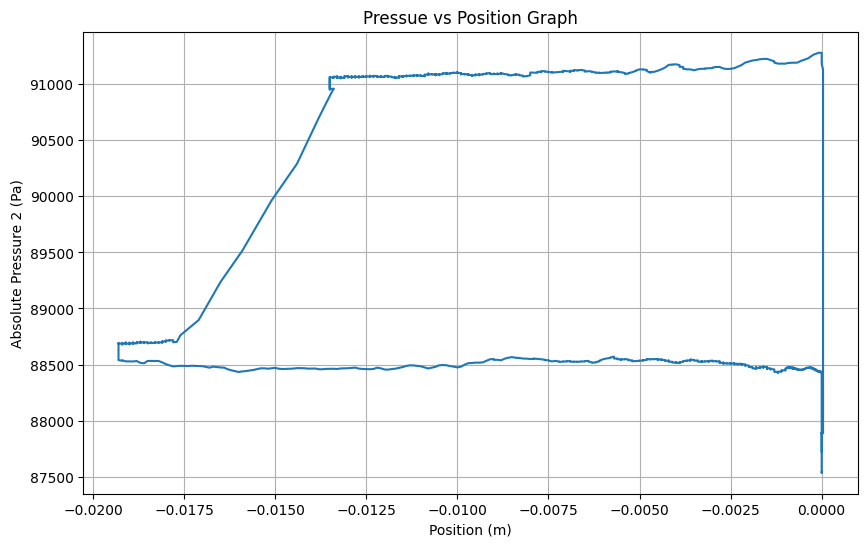

In [49]:
plt.figure(figsize=(10,6))
plt.plot(df['Position (m)'], df['Absolute Pressure 2 (Pa)'])

plt.xlabel('Position (m)')
plt.ylabel('Absolute Pressure 2 (Pa)')
plt.title('Pressue vs Position Graph')
plt.grid(True)

plt.show()

In [43]:
fig = px.line(df,
            x='Volume (cm³)', 
            y='Absolute Pressure 2 (Pa)', 
            title='Pressue vs Volume Graph', 
            hover_data=['Temperature 1 (°C)', 'Temperature 2 (°C)', df.index],
            markers=True, )
# fig.update_traces
fig.show(renderer='browser')

[2] Sandbox: CanCreateUserNamespace() clone() failure: EPERM


In [44]:
x = df['Position (m)'].values
P = df['Absolute Pressure 2 (Pa)'].values


def calculate_area(x_coords, y_coords):
    return 0.5 * np.abs(np.dot(x_coords, np.roll(y_coords, 1)) - np.dot(y_coords, np.roll(x_coords, 1)))

area_px = calculate_area(x, P)
print(f"Area of P-x curve: {area_px:.4f} Pa·m")

Area of P-x curve: 40.9219 Pa·m


In [ ]:
if 'Volume cm³)' in df.columns:
    V = df['Volume (cm³)'].values  # in m^3
    V = V /1000000
    work_joules = calculate_area(V, P)
    print(f"Net Work (P-V Area): {work_joules:.6f} J")
else:
    # If you need to calculate V from x:
    # V = V_dead + (A_piston * x)
    A_piston = np.pi * (0.0325 / 2)**2  # Standard 32.5mm piston
    V = A_piston * x
    work_joules = calculate_area(V, P)
    print(f"Calculated Net Work: {work_joules:.6f} J")

Calculated Net Work: 0.033948 J
